# Imports

In [1]:
# Imports
import numpy as np
from numpy import nan
import pandas as pd
import matplotlib.pyplot as plt
import os
import scipy
import scipy.stats as stats
from scipy.spatial.distance import cdist
import itertools
from tqdm.auto import tqdm
import seaborn as sns
import importlib
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import bernoulli

# Create GP world

In [278]:
## define the GP model
class GP_world():

    def __init__(self, N):
        
        ## initialise the GP grid
        self.N = N
        x = np.arange(N)
        y = np.arange(N)
        X,Y = np.meshgrid(x,y)
        self.locations = np.column_stack([X.ravel(), Y.ravel()])

        ## initialise the kernels
        self.K_lin = self.linear()
        self.K_lin_1D_x = self.linear_1D(dim=0)
        self.K_lin_1D_y = self.linear_1D(dim=1)
        self.K_rbf = self.rbf()
        self.K_rbf_1D_x = self.rbf_1D(dim=0)
        self.K_rbf_1D_y = self.rbf_1D(dim=1)
        self.K_periodic_x = self.periodic(dim=0)
        self.K_periodic_y = self.periodic(dim=1)




    #### define the kernels


    ## linear kernels
    
    # linear kernel over x,y, i.e. similarity as a function of the distance from the origin (0,0)
    def linear(self, c=0):
        dists = np.sqrt(self.locations[:, 0]**2 + self.locations[:, 1]**2)
        K = np.outer(dists, dists) + c
        return K
    
    # linear kernel over x-distance (0) or y-distance (1), i.e. similarity as a function of the distance from (0,:) or (:,0)
    def linear_1D(self, dim = 0, scale=1.0): 
        dists = np.subtract.outer(self.locations[:, dim], self.locations[:, dim])
        K = scale**2 * dists
        return K
    

    ## RBFs 

    # RBF kernel over x,y (i.e. Euclidean distance)
    def rbf(self, sigma_f=1.0, length_scale=2):
        dists = cdist(self.locations, self.locations, metric='euclidean')
        K = sigma_f**2 * np.exp(-0.5 * (dists / length_scale)**2)
        return K

    # RBF kernel over just x-distance or y-distance
    def rbf_1D(self, dim=0, sigma_f=1.0, length_scale=2):
        dists = np.subtract.outer(self.locations[:, dim], self.locations[:, dim])
        K = sigma_f**2 * np.exp(-0.5 * (dists / length_scale)**2)
        return K
    

    ## periodic kernel
    def periodic(self, dim=0, sigma_f=1.0, length_scale=4, period=8):
        # dists = cdist(self.locations, self.locations, metric='euclidean')
        dists = np.subtract.outer(self.locations[:, dim], self.locations[:, dim])
        K = sigma_f**2 * np.exp(-2 * np.sin(np.pi * dists / period)**2 / length_scale**2)
        return K
    
    ## __call__ Method
    # def __call__(self, kernel_types, **kwargs):
        
    #     ## composite kernel
    #     if isinstance(kernel_types, list):

    #         # if operations is None or len(kernel_types) != len(operation) + 1:
    #         #     raise ValueError("Must provide a list of operations with one less element than the list of kernels.")
            
    #         # start with the first kernel
    #         K_1 = self.compute_kernel(kernel_types[0], **kwargs)
    #         K_2 = self.compute_kernel(kernel_types[1], **kwargs)
    #         K = self.combine_kernels(K_1, K_2, kernel_types[2])

    #         # Combine the subsequent kernels
    #         # for i, op in enumerate(operations):
    #         #     K_next = self.compute_kernel(kernel_types[i+1], **kwargs)
    #         #     K = self.combine_kernels(K, K_next, operation=op)

    #     ## base kernel
    #     else:
    #         K = self.compute_kernel(kernel_types, **kwargs)
        
            
    #     return K
    
    # ## compute the kernel
    # def compute_kernel(self, kernel_type, **kwargs):
    #     if kernel_type == 'linear':
    #         return self.linear(**kwargs)
    #     elif kernel_type == 'linear_1D':
    #         return self.linear_1D(**kwargs)
    #     elif kernel_type == 'rbf':
    #         return self.rbf(**kwargs)
    #     elif kernel_type == 'rbf_1D':
    #         return self.rbf_1D(**kwargs)
    #     elif kernel_type == 'periodic':
    #         return self.periodic(**kwargs)
    #     else:
    #         raise ValueError(f"Unknown kernel type: {kernel_type}")
        
        
    ## combine the kernels
    # def combine_kernels(self, K1, K2, operation):
    #     if operation == '+':
    #         return K1 + K2
    #     elif operation == '*':
    #         return K1 * K2
    #     else:
    #         raise ValueError(f"Unknown operation: {operation}")

    ## sample from the GP
    def sample(self, K, **kwargs):
        # K = self(kernel_types, **kwargs)
        mean = np.zeros(self.N**2)
        samples = np.random.multivariate_normal(mean, K).reshape(self.N, self.N)
        return samples
    
    ## visualise the samples
    def plot_r(self, sampled_rewards, ax):
        ax.imshow(sampled_rewards, extent=(0, self.N, 0, self.N), origin='lower')
        ax.set_xticks(np.arange(0, self.N+1, 5))
        ax.set_yticks(np.arange(0, self.N+1, 5))
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        # ax.set_title('Sampled Reward Distribution,\nkernel: {}'.format(self.kernel_type))
        return ax
    

/var/folders/0_/bfm0814102bf5r7kyrp8f9tw19dth1/T/ipykernel_75054/102966309.py:121: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samples = np.random.multivariate_normal(mean, K).reshape(self.N, self.N)


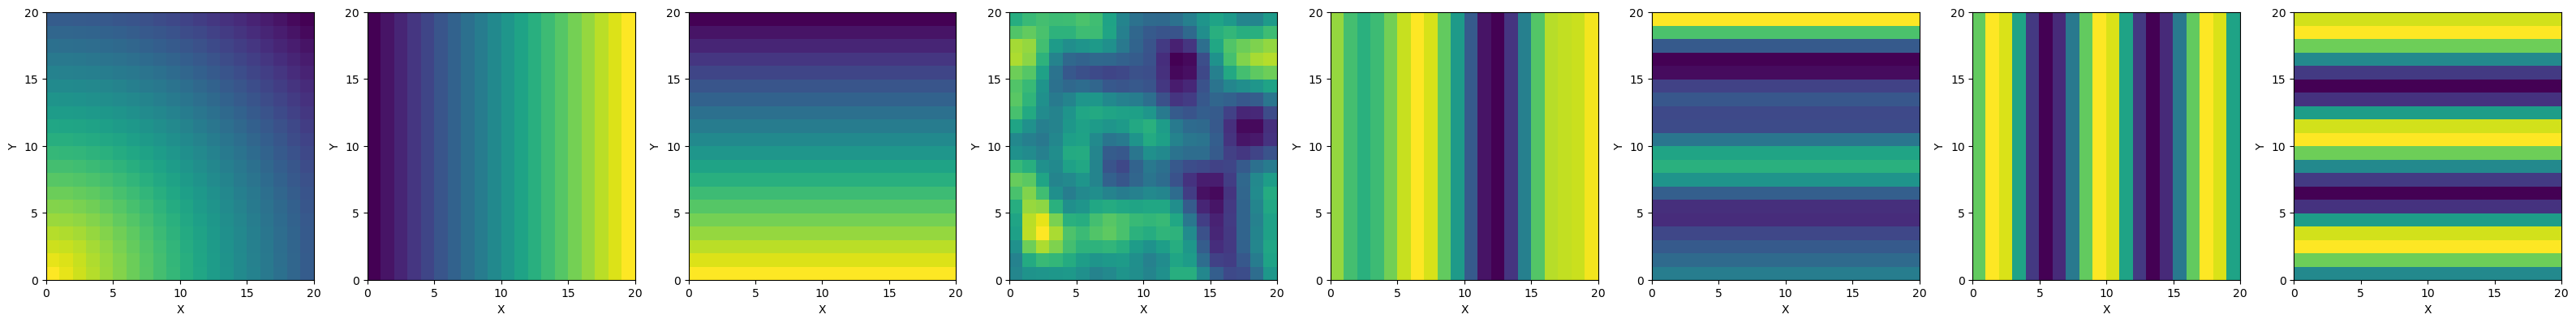

In [283]:
fig, axs = plt.subplots(1, n_koi, figsize=(5*n_koi, 5))

## initialise the GP
GP = GP_world(20)

## define kernels of interest
# koi = ['linear', 'linear_1D', 'rbf', 'rbf_1D','periodic', ['rbf', 'periodic','+']]
    #    , ['linear', 'rbf', 'linear', 'rbf']]
koi = [GP.K_lin, GP.K_lin_1D_x, GP.K_lin_1D_y, GP.K_rbf, GP.K_rbf_1D_x, GP.K_rbf_1D_y, GP.K_periodic_x, GP.K_periodic_y]
n_koi = len(koi)

## loop through kernel types and sample the GP under each kernel
for ki, k_type in enumerate(koi):
    samples = GP.sample(k_type)
    GP.plot_r(samples, axs[ki])

NameError: name 'plot_r' is not defined

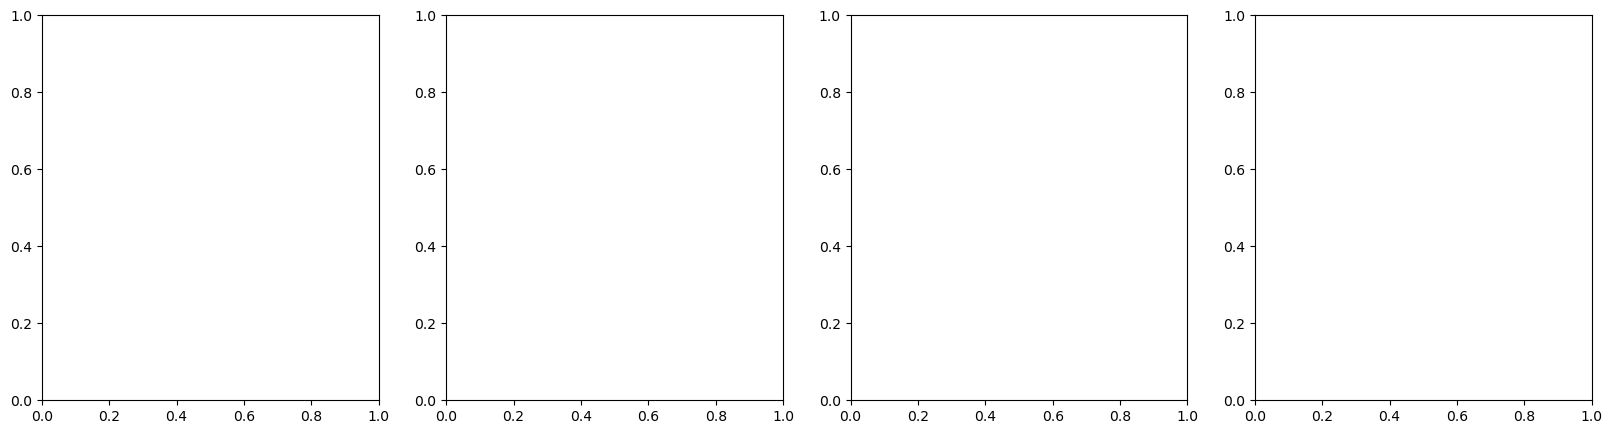

In [131]:
## initialise the city
N = 25
x = np.arange(0, N)
y = np.arange(0, N)
X, Y = np.meshgrid(x, y)
locations = np.column_stack([X.ravel(), Y.ravel()])

## define kernels of interest
koi = ['linear', 'linear_1D', 'rbf', 'rbf_1D']
n_koi = len(koi)
fig, axs = plt.subplots(1, n_koi, figsize=(5*n_koi, 5))
sigma_f = 1.0
length_scale = 2

## use each kernel to compute the covariance matrix for the current city
kernel = Kernel()
for ki, kernel_type in enumerate(koi):
    ax = axs[ki]
    K = kernel(locations, kernel_type)
    # K = kernel(locations, 'rbf', sigma_f=sigma_f, length_scale=length_scale)

    # sample from the GP
    mean = np.zeros(N**2)
    sampled_rewards = np.random.multivariate_normal(mean, K).reshape(N, N)

    ## visualize the sampled rewards
    ax = 

def plot_r(sampled_rewards, ax):
    ax.imshow(sampled_rewards, extent=(0, N, 0, N), origin='lower')
    ax.xticks(np.arange(0, N+1, 5))
    ax.yticks(np.arange(0, N+1, 5))
    ax.colorbar(label='Reward')
    ax.title('Sampled Reward Distribution')
    ax.xlabel('X')
    ax.ylabel('Y')
    return ax